#  저출산 관련 필수 진료과(소아청소년과·산부인과)의 지역별 의료 접근성 분석

---

## 0️⃣ 주제 정하기

- **분야**: 보건의료 — 저출산 관련 필수 진료과(소아청소년과, 산부인과)의 지역별 분포
- **선정 이유**: 최근 "소아과 오픈런", "분만 취약지" 등 저출산과 맞물린 의료 접근성 이슈가 사회적으로 주목받고 있어 선정
- **분석 대상 범위 설정**: 병원 종별(`clCdNm`) 중 **상급종합·종합병원**만을 분석 대상으로 한정함
  - 의원급은 입원 병상 29개 이하로 대부분 통원 진료 위주이며, 수술실·중환자실이 없어 실제 수술이나 고위험 분만·중증 소아 처치가 어려운 경우가 많음
  - 반면 종합병원 이상은 100병상 이상, 수술실·중환자실을 갖추고 있어 실질적인 중증 대응이 가능함
  - 상급종합만 보면 표본이 지나치게 적어지고, 지방에서는 종합병원이 사실상 그 지역의 최상위 대응 가능 기관 역할을 하는 경우가 많아 상급종합·종합병원을 함께 묶어 분석함
  - 즉 "진료과목이 등록된 병원 수"가 아니라 **"실제로 중증 상황에 대응할 수 있는 의료기관의 수"**를 보기 위한 필터링을 했다



## 1️⃣ 분석 질문 정하기

- **메인 질문**: 상급종합·종합병원 수준의 소아청소년과·산부인과가 지역(시도)별로 균등하게 분포되어 있는가? 단순 병원 개수가 아니라 인구 대비로 봤을 때도 그러한가?
- **세부 질문**
  - Q1. 단순 개수 기준으로, 시도별 상급종합·종합병원 수는 어떻게 다른가?
  - Q2. 인구 대비(100만 명당)로 보정하면 분포가 달라지는가?
  - Q3. 소아청소년과와 산부인과 사이에 지역 패턴이 비슷한가?



## 2️⃣ 수집 대상 선정

- **병원 데이터**
  - 출처: 공공데이터포털 — 건강보험심사평가원 병원정보서비스 (Open API)
  - URL: `https://apis.data.go.kr/B551182/hospInfoServicev2/getHospBasisList`
  - 수집 항목: 병원명(`yadmNm`), 시도명(`sidoCdNm`), 시군구명(`sgguCdNm`), 종별(`clCdNm`), 진료과목(`dgsbjtCd`: 소아청소년과=11, 산부인과=10)
- **인구 데이터**
  - 출처: 위키백과 "대한민국" 문서
  - URL: `https://ko.wikipedia.org/wiki/대한민국`
  - 수집 항목: 시도명, 주민등록인구(명)
- **윤리·법 확인**
  - 로그인 불필요, 개인정보 미포함
  - 공공데이터포털 API는 공식 제공 창구로 이용약관 문제 없음
  - 위키백과는 스크래핑에 관대한 정책 (robots.txt 상 허용)
  - 수집 일시: 2026-07-23



## 3️⃣ 데이터 수집 및 저장

- 병원 데이터: `requests`로 API 호출, 페이지네이션(`pageNo`, `numOfRows=100`)으로 소아청소년과·산부인과 통합 약 19,718건 수집 후 `pandas` DataFrame 변환
- 종별(`clCdNm`) 기준 **상급종합·종합병원만 필터링**
- 인구 데이터: `requests` + `BeautifulSoup`으로 위키백과 표(`wikitable`) 파싱, 구분 행·결측 지역(북한 지역 등) 필터링 후 17개 시도 확보
- CSV 저장: `hospital_pediatrics.csv`, `hospital_obgyn.csv`, `sido_population.csv`



## 4️⃣ 데이터 정제
- **시도명 표기 통일**: 병원 데이터는 "서울", "경기" 등 축약형, 인구 데이터는 "서울특별시", "경기도" 등 정식 명칭 → 매핑 딕셔너리로 통일, "세종시" → "세종"으로 재통일
- **"전남광주" 처리**: HIRA API에서 전라남도·광주광역시가 "전남광주"라는 하나의 시도 코드로 제공됨. 시군구명 기준 분리를 시도했으나 완전히 검증할 수 없어, **인구 데이터도 전남·광주 인구를 합산하여 "전남광주" 하나의 권역으로 처리** → 최종 분석 단위는 17개가 아닌 **16개 시도**
- **자료형 변환**: 인구수 콤마 포함 문자열(`"9,355,801"`) → 콤마 제거 후 정수(int) 변환
- **결측치·이상치 확인**: 병원 데이터 + 인구 데이터 병합 후 결측치 0건, 이상치 0건 (`quality_report_full` 함수로 확인)

### 최종 데이터(`final`) 컬럼 설명

| 컬럼명 | 설명 |
|---|---|
| `hs_시도명_clean` | 병원 데이터의 시도명 (인구 데이터와 표기 통일 완료, "전남광주" 포함 16개) |
| `소아청소년과_개수` | 해당 시도의 상급종합·종합병원 중 소아청소년과 표방 병원 수 |
| `산부인과_개수` | 해당 시도의 상급종합·종합병원 중 산부인과 표방 병원 수 |
| `인구수` | 해당 시도의 주민등록인구수(명), "전남광주"는 전남+광주 인구 합산값 |
| `소아청소년과_100만명당` | 인구 100만 명당 상급종합·종합병원 소아청소년과 수 (= 개수 ÷ 인구수 × 1,000,000) |
| `산부인과_100만명당` | 인구 100만 명당 상급종합·종합병원 산부인과 수 (= 개수 ÷ 인구수 × 1,000,000) |



## 5️⃣ 시각화로 살펴보기

- **Q1. 시도별 상급종합·종합병원 개수 (단순 비교)**
  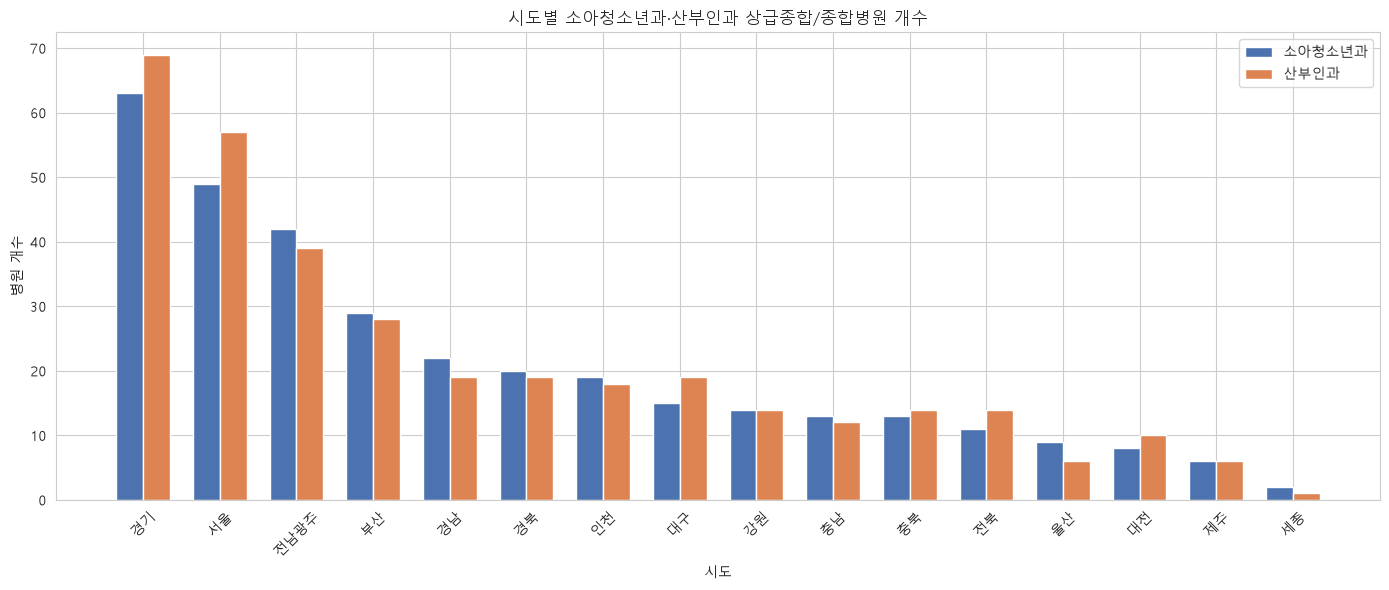
  - 경기(소아청소년과 63개·산부인과 69개)가 가장 많고 세종(소아청소년과 2개·산부인과 1개)이 가장 적어, 지역 간 최대 약 31~69배에 달하는 큰 차이를 보임
  - 서울(49개·57개), 전남광주(42개·39개)가 뒤를 이어 상위권을 형성하며, 상위 3개 지역이 나머지 지역과 뚜렷한 격차를 보임
  - 다만 이는 두 지역의 인구 규모 차이 때문일 가능성이 있어 인구 대비 재확인이 필요함

---

- **Q2. 인구 100만 명당 병원 수 (보정된 비교)**
  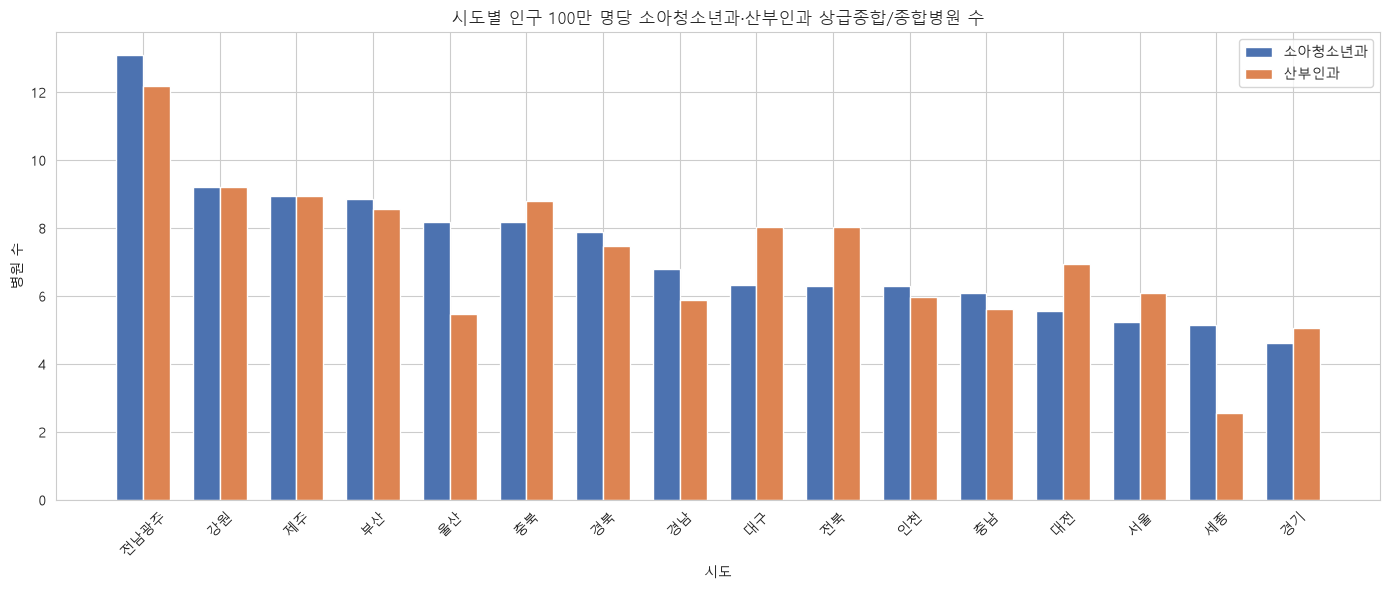
  - 인구 대비로 재계산하니 단순 개수 기준과는 정반대되는 순위가 나타남
  - 전남광주(합산 권역)가 소아청소년과 13.1개·산부인과 12.2개로 압도적 1위를 차지했고, 강원·제주·부산도 상위권에 속함
  - 반면 단순 개수로는 상위권이었던 서울(5.2개·6.1개)과 경기(4.6개·5.0개)는 오히려 최하위권으로 밀려남
  - 이는 서울·경기가 절대 병원 개수는 많지만 그만큼 인구도 많아, 인구 대비로는 상급 의료기관 집중도가 오히려 낮다는 것을 보여줌
  - 세종은 산부인과 기준 가장 낮은 수치(2.5개)로, 인구 대비로도 여전히 취약한 지역으로 확인됨
  
---

- **Q3. 소아청소년과 vs 산부인과 패턴 비교 (산점도)**
  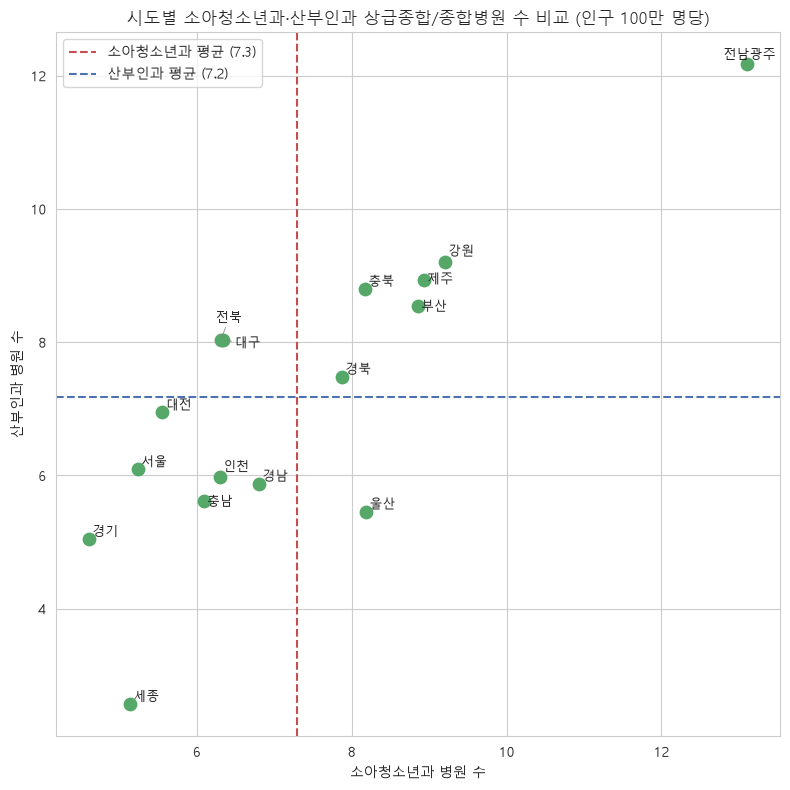
  - 평균(소아청소년과 7.3, 산부인과 7.2) 기준으로 전남광주·강원·제주·부산·충북·경북은 두 진료과목 모두 평균 이상인 반면, 서울·경기·인천·충남·경남·울산·세종은 두 진료과목 모두 평균 이하로 나타나 지역이 뚜렷하게 두 그룹으로 갈림
  - 전북·대구는 소아청소년과는 평균 이하이지만 산부인과는 평균 이상으로, 두 진료과목 간 균형이 지역마다 다르게 나타날 수 있음을 보여줌
  - 세종은 두 진료과목 모두 최하위권으로, 상급 의료기관 접근성이 가장 취약한 지역으로 확인됨



## 6️⃣ 마무리 정리

- **처음 질문**: 상급종합·종합병원 수준의 소아청소년과·산부인과가 지역별로 균등하게 분포되어 있는가?
- **알게 된 점**
  - 단순 개수 비교는 인구 규모에 따른 착시를 일으킬 수 있음 (경기·서울이 압도적으로 많아 보였으나 인구도 그만큼 많았음)
  - 인구 대비로 보정하면 순위가 정반대로 뒤집힘: 전남광주·강원·제주·부산이 상위권으로 올라서고, 서울·경기는 오히려 하위권으로 밀려남
  - 수도권(서울·경기·인천)은 동네 의원 수준 접근성은 높을 수 있으나, 정작 중증 상황에 대응 가능한 상급 의료기관의 인구 대비 밀도는 낮다는 점이 확인됨
  - 세종은 두 진료과목 모두 최하위권으로, 상급 의료기관 기준 의료 접근성이 가장 취약한 지역으로 나타남
- **한계**
  - '진료과목 등록 여부'만 확인 가능하며, 실제 시설·인력에 대해서는 별도 데이터 필요
  - HIRA API의 "전남광주" 통합 코드로 인해 전남·광주를 개별 비교하지 못함
  - 상급종합·종합병원으로 한정하면서 표본 수가 크게 줄어(예: 세종 1~2개), 일부 지역은 소수 병원의 변동에도 통계치가 크게 흔들릴 수 있음
- **후속 질문**
  - 전남·광주를 시군구 단위로 명확히 분리할 수 있는 데이터 확보 가능한지
  - 상급종합병원과 종합병원을 나눠서 별도로 비교하면, 그 안에서도 등급별 격차가 있는지